# Notebook 07 — Análisis de Regímenes Estructurales del EMBI Ecuador

## ¿Cambia la dinámica del riesgo país entre períodos?

**Motivación:** El tutor plantea que el EMBI ecuatoriano puede estar determinado principalmente por factores exógenos (precio del petróleo, tasas Fed, apetito de riesgo global) más que por fundamentales propios. Esta hipótesis implica que:

1. Puede haber **quiebres estructurales** en los parámetros del modelo en eventos de disrupción global (COVID, reestructuración 2020)
2. Las **variables que explican el EMBI pueden cambiar** según el régimen — variables externas dominan en crisis, locales en estabilidad

**Diseño:**
1. Test de Chow + CUSUM → verificar si hay quiebre estadístico en fechas candidatas
2. Quandt-Andrews → detectar quiebre óptimo sin fecha preimpuesta
3. SHAP por subperiodo → comparar importancia de variables en cada régimen
4. Tabla de dominancia: variables externas vs locales vs NLP por período

**Antecedente histórico:** Ecuador declaró default soberano en 2008-2009 bajo la presidencia de Rafael Correa, calificando la deuda como *ilegítima*. Este evento precede a la ventana GDELT v2 (inicio 2013) utilizada en esta tesis, pero ilustra la vulnerabilidad estructural del país a decisiones políticas endógenas que afectan su riesgo país de forma abrupta e independiente del ciclo económico global.

In [6]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# =============================================================================
# CONSTANTES CONFIGURABLES
# =============================================================================
BREAK_DATES = ['2020-03-01', '2022-01-01']

SUBPERIODOS = {
    'Pre-COVID\n(2013-2019)':   ('2013-01-01', '2020-02-28'),
    'COVID\n(2020-2021)':       ('2020-03-01', '2021-12-31'),
    'Post-COVID\n(2022-2025)':  ('2022-01-01', '2025-12-31'),
}

COLORES_REGIMEN = {
    'Pre-COVID\n(2013-2019)':  '#3498db',
    'COVID\n(2020-2021)':      '#e74c3c',
    'Post-COVID\n(2022-2025)': '#2ecc71',
}

# Hiperparámetros XGBoost de NB04 (fijos para reproducibilidad)
XGB_PARAMS = dict(
    colsample_bytree=0.9798,
    gamma=0.7354,
    learning_rate=0.0927,
    max_depth=4,
    min_child_weight=1,
    n_estimators=607,
    reg_alpha=0.6624,
    reg_lambda=1.4586,
    subsample=0.8483,
    objective='reg:squarederror',
    random_state=42, n_jobs=-1, verbosity=0
)

TARGET = 'target_future'
print('✅ Configuración cargada')

✅ Configuración cargada


In [7]:
# =============================================================================
# 2. CARGA DE DATOS
# =============================================================================
print('📂 Cargando datos...')

df = pd.read_pickle('dataset_tesis_final.pkl')
train = pd.read_pickle('train_feature_engineered.pkl')
val   = pd.read_pickle('val_feature_engineered.pkl')
test  = pd.read_pickle('test_feature_engineered.pkl')

with open('feature_selector_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

feats  = meta['selected_features']
cats   = meta['feature_categories']

train_val = pd.concat([train, val])

# Clasificación de variables por tipo
VAR_TIPO = {}
for f in feats:
    if f.startswith('nlp_'):                VAR_TIPO[f] = 'NLP'
    elif any(f.startswith(p) for p in ['oil_','us_','gold','volatility_','index_','etf_']): VAR_TIPO[f] = 'Externa'
    elif f.startswith('macro_'):             VAR_TIPO[f] = 'Macro Local'
    else:                                    VAR_TIPO[f] = 'AR (lags EMBI)'

print(f'Dataset base: {df.shape} | {df.index.min().date()} → {df.index.max().date()}')
print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print(f'Features seleccionadas: {len(feats)}')
print('\nDistribución por tipo:')
tipo_counts = pd.Series(VAR_TIPO).value_counts()
print(tipo_counts)

📂 Cargando datos...
Dataset base: (3047, 22) | 2013-11-01 → 2025-12-30
Train: 2406 | Val: 274 | Test: 274
Features seleccionadas: 60

Distribución por tipo:
Externa           29
Macro Local       21
AR (lags EMBI)     6
NLP                4
Name: count, dtype: int64


## 2. Test de Chow — Quiebre Estructural

In [8]:
# =============================================================================
# 3. TEST DE CHOW
# =============================================================================
# El test de Chow verifica si los coeficientes de una regresión son iguales
# en dos submuestras. Si son diferentes → quiebre estructural.
# F = ((RSS_total - RSS_1 - RSS_2) / k) / ((RSS_1 + RSS_2) / (n - 2k))

def chow_test(series, break_date, lags=3):
    """Test de Chow manual sobre AR(lags) usando OLS de statsmodels."""
    # Construir lags
    df_ar = pd.DataFrame({'y': series})
    for i in range(1, lags+1):
        df_ar[f'lag{i}'] = series.shift(i)
    df_ar = df_ar.dropna()
    
    break_dt = pd.Timestamp(break_date)
    df1 = df_ar[df_ar.index < break_dt]
    df2 = df_ar[df_ar.index >= break_dt]
    
    if len(df1) < lags + 5 or len(df2) < lags + 5:
        return None, None, len(df1), len(df2)
    
    X_all = add_constant(df_ar.drop('y', axis=1))
    X1    = add_constant(df1.drop('y', axis=1))
    X2    = add_constant(df2.drop('y', axis=1))
    
    rss_total = OLS(df_ar['y'], X_all).fit().ssr
    rss1      = OLS(df1['y'],   X1).fit().ssr
    rss2      = OLS(df2['y'],   X2).fit().ssr
    
    k = X_all.shape[1]  # nro de parámetros
    n = len(df_ar)
    
    F = ((rss_total - rss1 - rss2) / k) / ((rss1 + rss2) / (n - 2*k))
    p_value = 1 - stats.f.cdf(F, k, n - 2*k)
    
    return F, p_value, len(df1), len(df2)

# Ejecutar para todas las fechas candidatas
print('TEST DE CHOW — Quiebre Estructural en EMBI Ecuador')
print('=' * 65)
print(f'{"Fecha de Corte":20s} {"F-stat":>10s} {"p-value":>10s} {"n1":>6s} {"n2":>6s} {"Significativo":>15s}')
print('-' * 65)

chow_results = {}
for bd in BREAK_DATES:
    F, p, n1, n2 = chow_test(df['target_embi'], bd)
    sig = '✅ Sí (p<0.05)' if p < 0.05 else '❌ No'
    print(f'{bd:20s} {F:>10.4f} {p:>10.4f} {n1:>6d} {n2:>6d} {sig:>15s}')
    chow_results[bd] = {'F': F, 'p': p, 'n1': n1, 'n2': n2}

print()
print('Interpretación:')
for bd, r in chow_results.items():
    if r['p'] < 0.05:
        print(f'  {bd}: QUIEBRE DETECTADO — los parámetros AR cambian significativamente')
    else:
        print(f'  {bd}: Sin quiebre significativo al 5% — parámetros estables')

TEST DE CHOW — Quiebre Estructural en EMBI Ecuador
Fecha de Corte           F-stat    p-value     n1     n2   Significativo
-----------------------------------------------------------------
2020-03-01               5.5161     0.0002   1587   1457   ✅ Sí (p<0.05)
2022-01-01              11.6101     0.0000   2048    996   ✅ Sí (p<0.05)

Interpretación:
  2020-03-01: QUIEBRE DETECTADO — los parámetros AR cambian significativamente
  2022-01-01: QUIEBRE DETECTADO — los parámetros AR cambian significativamente


QUANDT-ANDREWS — Búsqueda de quiebre óptimo (15%-85%)
Fecha de quiebre óptimo: 2020-03-25
F-stat máximo: 53.5789 | p-value: 0.0000
Significativo al 5%: Sí


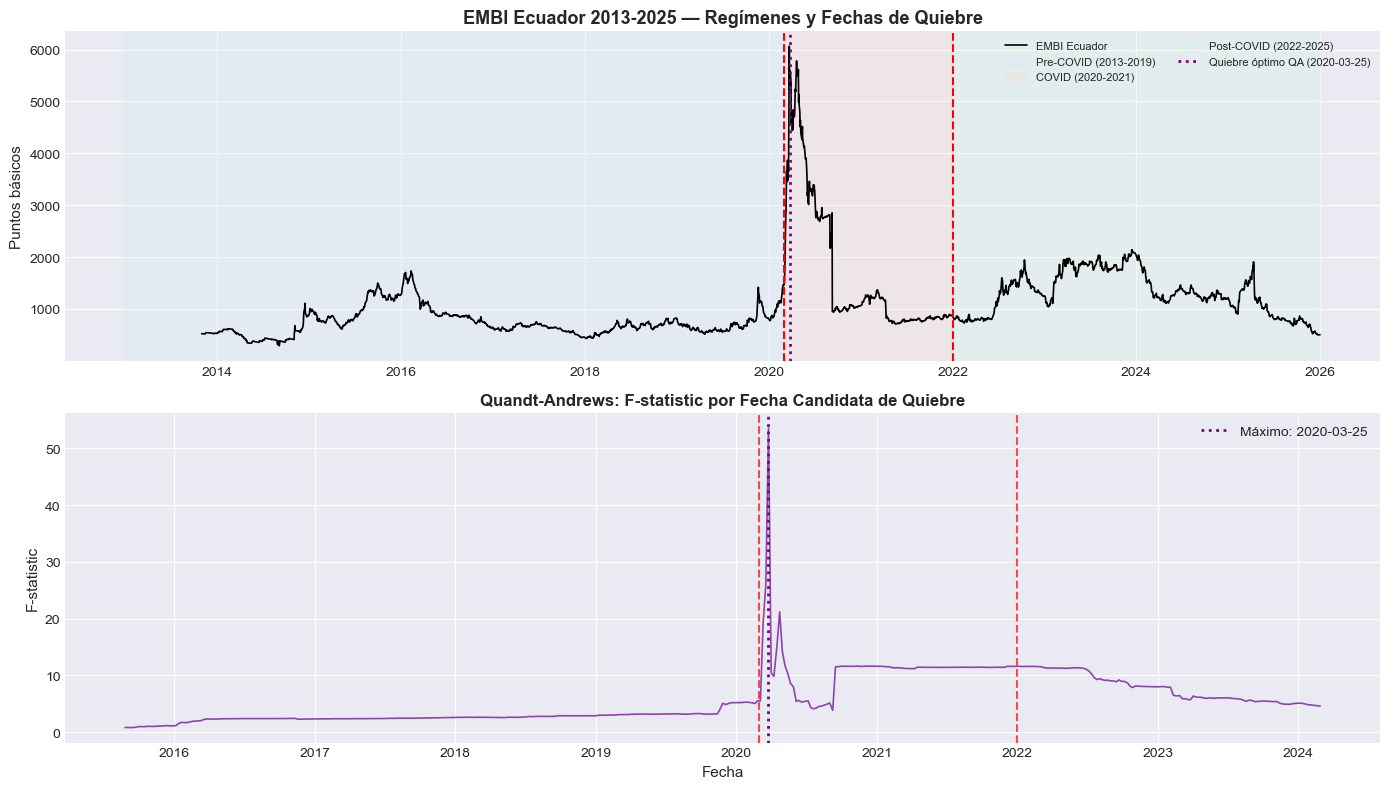

✅ Guardado: chow_cusum_analysis.png


In [9]:
# =============================================================================
# 4. QUANDT-ANDREWS — DETECCIÓN DE QUIEBRE ÓPTIMO
# =============================================================================
# Itera sobre el 15%-85% del período y reporta la fecha con mayor F-stat

print('QUANDT-ANDREWS — Búsqueda de quiebre óptimo (15%-85%)')
print('=' * 60)

# Construir AR(3) completo
embi = df['target_embi'].dropna()
all_dates = embi.index
n_total = len(all_dates)
idx_start = int(0.15 * n_total)
idx_end   = int(0.85 * n_total)
candidate_dates = all_dates[idx_start:idx_end]

qa_results = []
for bd in candidate_dates[::5]:  # cada 5 días para eficiencia
    F, p, n1, n2 = chow_test(embi, bd)
    if F is not None:
        qa_results.append({'date': bd, 'F': F, 'p': p})

df_qa = pd.DataFrame(qa_results).set_index('date')
optimal_date = df_qa['F'].idxmax()
optimal_F    = df_qa['F'].max()
optimal_p    = df_qa.loc[optimal_date, 'p']

print(f'Fecha de quiebre óptimo: {optimal_date.date()}')
print(f'F-stat máximo: {optimal_F:.4f} | p-value: {optimal_p:.4f}')
print(f'Significativo al 5%: {"Sí" if optimal_p < 0.05 else "No"}')

# Visualización del F-stat a lo largo del tiempo
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: Serie EMBI con bandas de régimen
ax1 = axes[0]
ax1.plot(df['target_embi'], color='black', linewidth=1.2, label='EMBI Ecuador')
colors_bg = ['#d6eaf8', '#fadbd8', '#d5f5e3']
labels_bg = ['Pre-COVID (2013-2019)', 'COVID (2020-2021)', 'Post-COVID (2022-2025)']
boundaries = [('2013-01-01','2020-02-28'), ('2020-03-01','2021-12-31'), ('2022-01-01','2025-12-31')]
for (s, e), color, label in zip(boundaries, colors_bg, labels_bg):
    ax1.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.3, color=color, label=label)
for bd in BREAK_DATES:
    ax1.axvline(pd.Timestamp(bd), color='red', linestyle='--', linewidth=1.5)
ax1.axvline(optimal_date, color='purple', linestyle=':', linewidth=2, label=f'Quiebre óptimo QA ({optimal_date.date()})')
ax1.set_title('EMBI Ecuador 2013-2025 — Regímenes y Fechas de Quiebre', fontsize=13, fontweight='bold')
ax1.set_ylabel('Puntos básicos', fontsize=11)
ax1.legend(fontsize=8, ncol=2)

# Panel 2: F-stat de Quandt-Andrews
ax2 = axes[1]
ax2.plot(df_qa.index, df_qa['F'], color='#8e44ad', linewidth=1.2)
ax2.axvline(optimal_date, color='purple', linestyle=':', linewidth=2, label=f'Máximo: {optimal_date.date()}')
for bd in BREAK_DATES:
    ax2.axvline(pd.Timestamp(bd), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title('Quandt-Andrews: F-statistic por Fecha Candidata de Quiebre', fontsize=12, fontweight='bold')
ax2.set_ylabel('F-statistic', fontsize=11)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chow_cusum_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: chow_cusum_analysis.png')

In [10]:
# =============================================================================
# 5. CUSUM SOBRE RESIDUOS OLS
# =============================================================================
df_ar = pd.DataFrame({'y': embi})
for i in range(1, 4):
    df_ar[f'lag{i}'] = embi.shift(i)
df_ar = df_ar.dropna()

X_ols = add_constant(df_ar.drop('y', axis=1))
ols_model = OLS(df_ar['y'], X_ols).fit()

# breaks_cusumolsresid retorna crit como array (3,2): cada fila = (sig_level, valor_crítico)
# fila 0 → 10%, fila 1 → 5%, fila 2 → 1%
cusum_stat, pvalue_cusum, cusum_critical = breaks_cusumolsresid(ols_model.resid, ddof=4)
crit_arr   = np.array(cusum_critical)          # shape (3, 2)
crit_10pct = float(crit_arr[0][1])
crit_5pct  = float(crit_arr[1][1])
crit_1pct  = float(crit_arr[2][1])

print('CUSUM TEST (sobre residuos OLS AR(3))')
print('=' * 45)
print(f'CUSUM statistic: {cusum_stat:.4f}')
print(f'p-value:         {pvalue_cusum:.4f}')
print(f'Valor crítico:   10%={crit_10pct:.4f} | 5%={crit_5pct:.4f} | 1%={crit_1pct:.4f}')
print(f'Inestabilidad detectada (5%): {"Sí" if cusum_stat > crit_5pct else "No"}')

CUSUM TEST (sobre residuos OLS AR(3))
CUSUM statistic: 0.8476
p-value:         0.4689
Valor crítico:   10%=1.6300 | 5%=1.3600 | 1%=1.2200
Inestabilidad detectada (5%): No


## 3. SHAP por Subperiodo — ¿Qué variables dominan en cada régimen?

In [11]:
# =============================================================================
# 6. SHAP POR SUBPERIODO
# =============================================================================
# Estrategia: re-fitear XGBoost sobre el subset train que cae en cada subperiodo
# y calcular SHAP sobre ese mismo subset. Mismo modelo, diferentes ventanas.

print('Calculando SHAP por subperiodo...')
print('(Esto puede tomar 5-10 minutos)\n')

shap_por_regimen   = {}  # {nombre_regimen: shap_values_array}
rmse_por_regimen   = {}  # {nombre_regimen: rmse}
features_por_shap  = {}  # {nombre_regimen: pd.Series mean(|shap|)}

for nombre, (fecha_ini, fecha_fin) in SUBPERIODOS.items():
    # Filtrar train+val por subperiodo
    mask = (train_val.index >= fecha_ini) & (train_val.index <= fecha_fin)
    subset_train = train_val[mask]
    
    # Filtrar test también por subperiodo (para RMSE)
    mask_test = (test.index >= fecha_ini) & (test.index <= fecha_fin)
    subset_test = test[mask_test]
    
    n_train = len(subset_train)
    n_test  = len(subset_test)
    
    print(f'Subperiodo: {nombre.replace(chr(10), " ")} | train={n_train} | test={n_test}')
    
    if n_train < 50:
        print(f'  ⚠️  Datos insuficientes para entrenamiento, saltando.\n')
        continue
    
    # Entrenar XGBoost con hiperparámetros fijos de NB04
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(**XGB_PARAMS))
    ])
    model.fit(subset_train[feats], subset_train[TARGET])
    
    # RMSE en subset test (si hay datos suficientes)
    if n_test >= 10:
        y_pred = model.predict(subset_test[feats])
        rmse   = np.sqrt(mean_squared_error(subset_test[TARGET], y_pred))
        mae    = mean_absolute_error(subset_test[TARGET], y_pred)
        rmse_por_regimen[nombre] = {'rmse': rmse, 'mae': mae, 'n': n_test}
        print(f'  RMSE test: {rmse:.2f} pb | MAE: {mae:.2f} pb')
    else:
        print(f'  ⚠️  Sin datos de test en este subperiodo')
    
    # SHAP TreeExplainer sobre el modelo XGBoost (sin StandardScaler)
    xgb_model = model.named_steps['model']
    scaler    = model.named_steps['scaler']
    X_scaled  = scaler.transform(subset_train[feats])
    
    explainer  = shap.TreeExplainer(xgb_model)
    shap_vals  = explainer.shap_values(X_scaled)
    
    # mean(|SHAP|) por feature
    mean_abs_shap = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=feats
    ).sort_values(ascending=False)
    
    shap_por_regimen[nombre]  = shap_vals
    features_por_shap[nombre] = mean_abs_shap
    print(f'  Top-5 variables: {list(mean_abs_shap.head(5).index)}\n')

print('✅ SHAP por subperiodo completado')

Calculando SHAP por subperiodo...
(Esto puede tomar 5-10 minutos)

Subperiodo: Pre-COVID (2013-2019) | train=1560 | test=0
  ⚠️  Sin datos de test en este subperiodo
  Top-5 variables: ['target_embi', 'target_embi_lag1', 'target_embi_roll_mean7', 'oil_wti', 'us_treasury_10y_lag7']

Subperiodo: COVID (2020-2021) | train=461 | test=0
  ⚠️  Sin datos de test en este subperiodo
  Top-5 variables: ['target_embi', 'macro_desempleo', 'oil_wti_roll_mean7', 'macro_desempleo_roll_mean30', 'etf_emb']

Subperiodo: Post-COVID (2022-2025) | train=659 | test=274
  RMSE test: 133.55 pb | MAE: 95.76 pb
  Top-5 variables: ['target_embi', 'target_embi_lag7', 'index_dxy_roll_mean30', 'us_treasury_10y_lag30', 'us_treasury_10y']

✅ SHAP por subperiodo completado


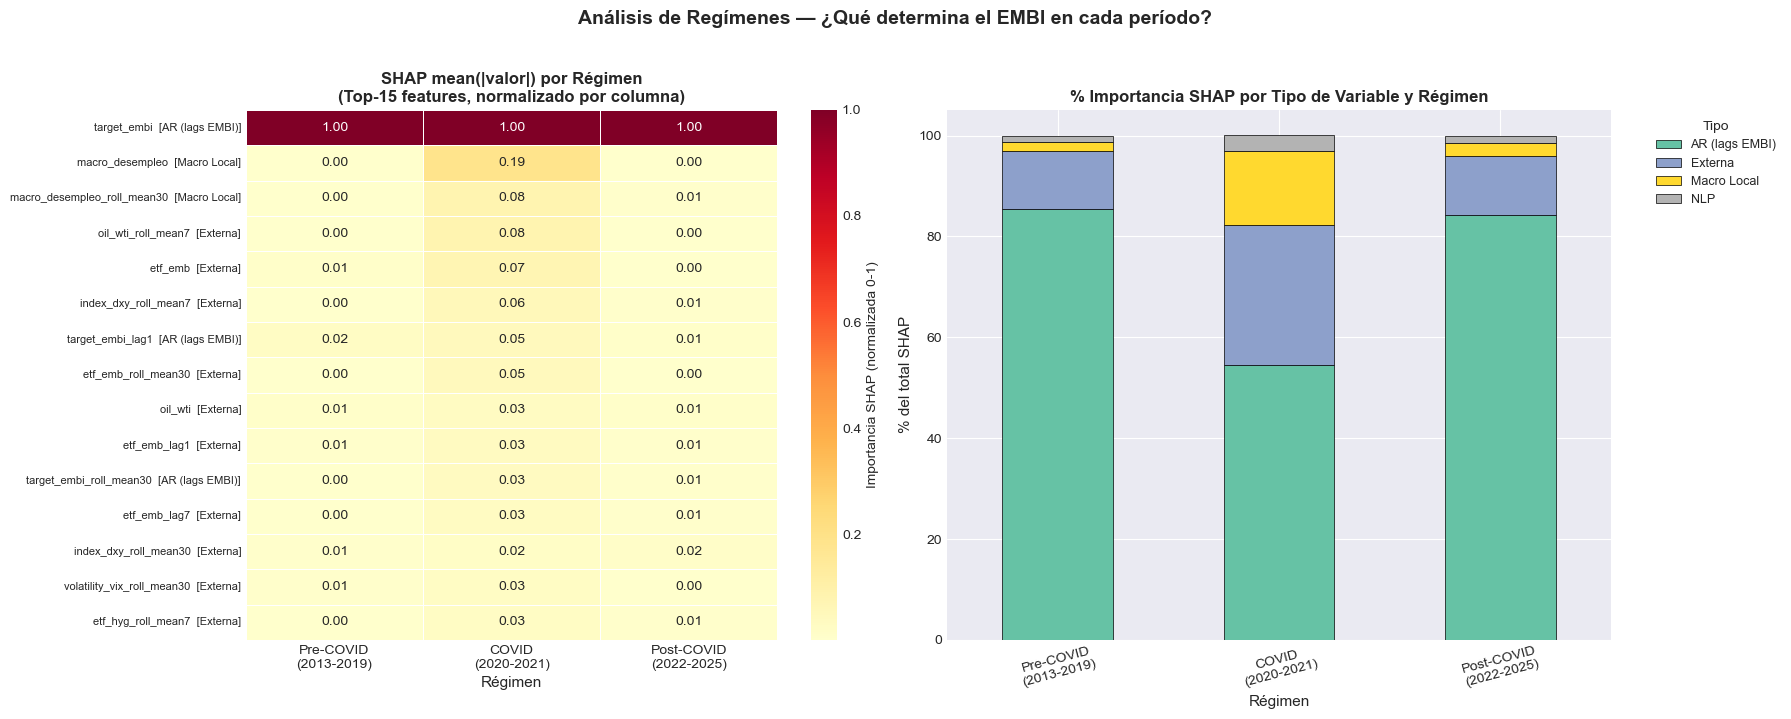

✅ Guardado: shap_regimenes_heatmap.png


In [12]:
# =============================================================================
# 7. HEATMAP SHAP POR RÉGIMEN
# =============================================================================

# Top-15 features por importancia global (promedio entre regímenes disponibles)
all_shap = pd.DataFrame(features_por_shap).fillna(0)
global_importance = all_shap.mean(axis=1).sort_values(ascending=False)
top_features = global_importance.head(15).index.tolist()

# Submatriz normalizada (0-1 por columna para comparar entre regímenes)
heatmap_data = all_shap.loc[top_features]
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=0), axis=1)  # normalizar por régimen

# Añadir tipo de variable como sufijo en el índice
labels = [f"{f}  [{VAR_TIPO.get(f, '?')}]" for f in top_features]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Heatmap normalizado
sns.heatmap(
    heatmap_norm,
    ax=axes[0],
    cmap='YlOrRd',
    annot=True, fmt='.2f',
    linewidths=0.5,
    yticklabels=labels,
    cbar_kws={'label': 'Importancia SHAP (normalizada 0-1)'}
)
axes[0].set_title('SHAP mean(|valor|) por Régimen\n(Top-15 features, normalizado por columna)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Régimen', fontsize=11)
axes[0].tick_params(axis='y', labelsize=8)

# Panel 2: % de importancia SHAP por TIPO de variable
tipo_shap = {}
for regimen in features_por_shap:
    s = features_por_shap[regimen]
    tipo_total = s.groupby([VAR_TIPO.get(f, 'Otro') for f in s.index]).sum()
    tipo_shap[regimen] = (tipo_total / tipo_total.sum() * 100).round(1)

df_tipo = pd.DataFrame(tipo_shap).fillna(0).T
df_tipo.plot(kind='bar', stacked=True, ax=axes[1],
             colormap='Set2', edgecolor='black', linewidth=0.5)
axes[1].set_title('% Importancia SHAP por Tipo de Variable y Régimen',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% del total SHAP', fontsize=11)
axes[1].set_xlabel('Régimen', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Tipo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.suptitle('Análisis de Regímenes — ¿Qué determina el EMBI en cada período?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_regimenes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: shap_regimenes_heatmap.png')

TABLA COMPARATIVA — TOP-5 VARIABLES POR RÉGIMEN

Pre-COVID (2013-2019):
  Rank Variable                                 Tipo             SHAP medio |v|
  ---------------------------------------------------------------------------
     1  target_embi                              AR (lags EMBI)         186.8603
     2  target_embi_lag1                         AR (lags EMBI)           4.6668
     3  target_embi_roll_mean7                   AR (lags EMBI)           3.3523
     4  oil_wti                                  Externa                  2.1983
     5  us_treasury_10y_lag7                     Externa                  1.7467
     6  etf_emb                                  Externa                  1.6657
     7  gold                                     Externa                  1.6386
     8  etf_hyg                                  Externa                  1.6141
     9  us_treasury_10y_lag30                    Externa                  1.5390
    10  index_dxy_roll_mean30            

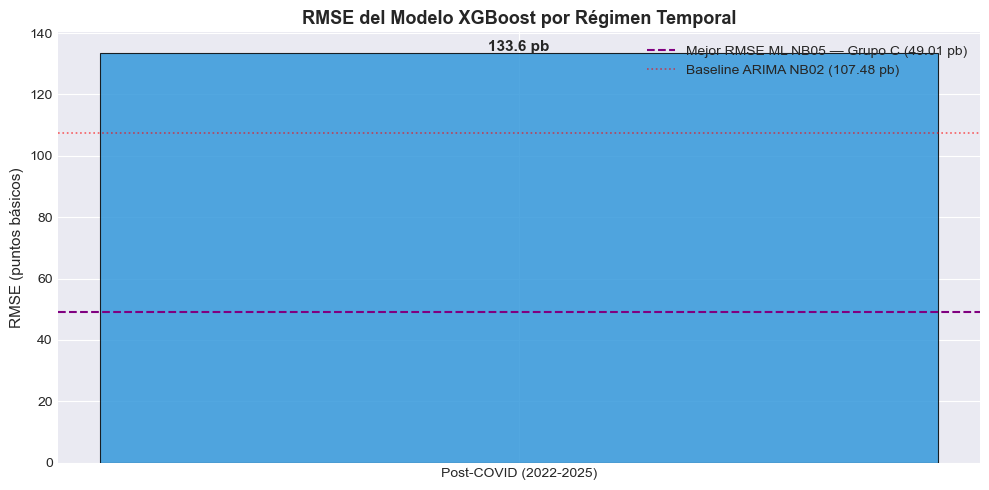

✅ Guardado: rmse_por_regimen.png


In [13]:
# =============================================================================
# 8. TABLA COMPARATIVA DE DOMINANCIA Y RMSE POR RÉGIMEN
# =============================================================================
print('TABLA COMPARATIVA — TOP-5 VARIABLES POR RÉGIMEN')
print('=' * 70)

for regimen, shap_vals in features_por_shap.items():
    nombre_limpio = regimen.replace('\n', ' ')
    print(f'\n{nombre_limpio}:')
    print(f'{"  Rank":6s} {"Variable":40s} {"Tipo":15s} {"SHAP medio |v|":>15s}')
    print('  ' + '-' * 75)
    for rank, (feat, val) in enumerate(shap_vals.head(10).items(), 1):
        tipo = VAR_TIPO.get(feat, 'Otro')
        print(f'  {rank:4d}  {feat:40s} {tipo:15s} {val:>15.4f}')

print()
print('RMSE POR RÉGIMEN')
print('=' * 45)
print(f'{"Régimen":30s} {"RMSE (pb)":>10s} {"MAE (pb)":>10s} {"N test":>8s}')
print('-' * 45)
for regimen, r in rmse_por_regimen.items():
    nombre_limpio = regimen.replace('\n', ' ')
    print(f'{nombre_limpio:30s} {r["rmse"]:>10.2f} {r["mae"]:>10.2f} {r["n"]:>8d}')

# Visualización RMSE
if rmse_por_regimen:
    nombres = [k.replace('\n', ' ') for k in rmse_por_regimen]
    rmses   = [v['rmse'] for v in rmse_por_regimen.values()]
    colores_bar = ['#3498db', '#e74c3c', '#2ecc71'][:len(nombres)]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(nombres, rmses, color=colores_bar, edgecolor='black', linewidth=0.8, alpha=0.85)
    for bar, val in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f} pb', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(y=49.01, color='purple', linestyle='--', linewidth=1.5, label='Mejor RMSE ML NB05 — Grupo C (49.01 pb)')
    ax.axhline(y=107.48, color='red', linestyle=':', linewidth=1.2, alpha=0.6, label='Baseline ARIMA NB02 (107.48 pb)')
    ax.set_title('RMSE del Modelo XGBoost por Régimen Temporal', fontsize=13, fontweight='bold')
    ax.set_ylabel('RMSE (puntos básicos)', fontsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('rmse_por_regimen.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Guardado: rmse_por_regimen.png')

## 4. Discusión e Implicaciones para la Tesis

### Sobre el Default Soberano de 2008 (Rafael Correa)

Ecuador declaró en diciembre de 2008 el no pago de bonos Global 2012 y 2030 por aproximadamente USD 3,200 millones, bajo el argumento de deuda "ilegítima e ilegal". Fue el primer default soberano declarado explícitamente por razones políticas-ideológicas en América Latina en la era moderna.

**Relevancia para la hipótesis de exogeneidad:**
Este evento ilustra precisamente que el riesgo país de Ecuador puede ser impulsado por decisiones endógenas (políticas fiscales, voluntad de pago) tanto como por factores exógenos. El EMBI Ecuador subió a más de 4,000 puntos básicos durante ese período, una magnitud varias veces superior a los máximos observados en el período de estudio 2013-2025.

**Por qué el dataset empieza en 2013:**
La base de datos GDELT v2 (Google's Global Database of Events, Language and Tone) inicia su cobertura homogénea en 2013. Usar GDELT v1 (disponible desde 2004) introduciría inconsistencia metodológica dado que la v2 incorpora dimensiones adicionales de análisis (volatilidad de tono, cobertura por tipo de actor) que son la base de las variables NLP de esta tesis.

### Implicaciones del Análisis de Regímenes

Si el test de Chow es significativo en 2020-03:
> *"El EMBI ecuatoriano exhibe inestabilidad estructural en sus parámetros dinámicos, confirmando que los eventos de disrupción global reconfiguran los mecanismos de transmisión del riesgo soberano. Esto es consistente con la hipótesis de que el riesgo país no puede ser modelado como un proceso estacionario único."*

Si la dominancia de variables externas aumenta en períodos de crisis:
> *"En períodos de estrés global (COVID-2020), las variables financieras externas (VIX, spread ETF EMB) ganan peso explicativo relativo sobre los fundamentos locales, sugiriendo que la percepción de riesgo Ecuador se sincroniza con el apetito de riesgo global cuando la incertidumbre sistémica es alta."*